
Tolerance = 0.001
Jacobi iterations: 4
Gauss-Seidel iterations: 4

Tolerance = 1e-06
Jacobi iterations: 7
Gauss-Seidel iterations: 5

Tolerance = 1e-09
Jacobi iterations: 9
Gauss-Seidel iterations: 7


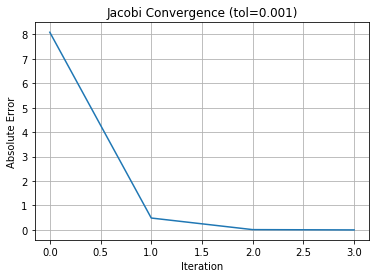

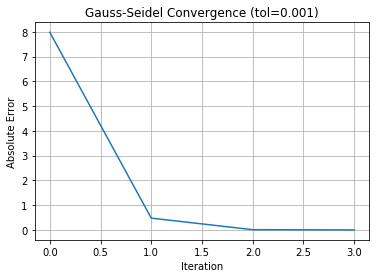

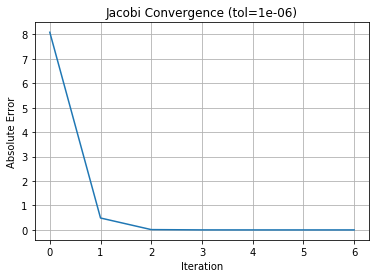

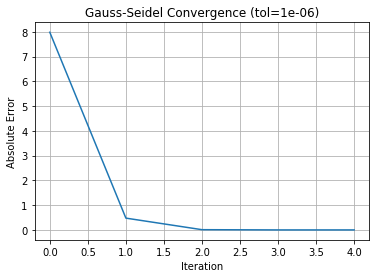

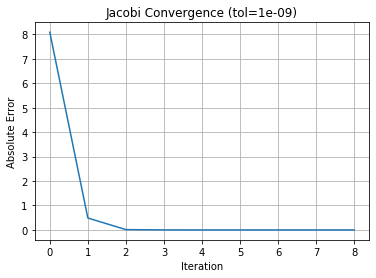

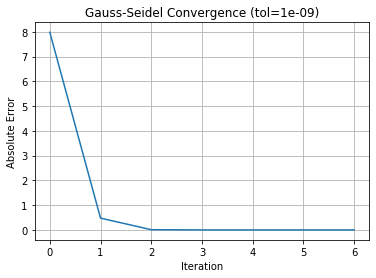

In [9]:

#Discuss: When we lower the tolerance as we go from 10^-3 to 10^-9 the number of iterations needed for
#convergence increases because more accuracy is needed. For all three sets of tolerances the Gauss-Seidel
#method converges in fewer iterations compared to the Jacobi method. I beleive this is due to the Seidel
#method using updated values each iteration instead of using the previous iteration values. 

import numpy as np
import matplotlib.pyplot as plt

A = np.array([
    [3.0, -0.1, -0.2],
    [0.1, 7.0, -0.3],
    [0.3, -0.2, 10.0]
]) #turn the given system of equations into an array

b = np.array([7.85, -19.3, 71.4])
x0 = np.zeros(3)
max_iterations = 500


def jacobi(A, b, x0, tol, max_iterations): #jacobi function mostly referenced from the slides
    n = len(b)
    x = x0.copy()
    errors = []

    for k in range(max_iterations):
        x_new = np.zeros_like(x)

        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]

        error = np.linalg.norm(x_new - x)
        errors.append(error)

        if error < tol:
            return x_new, k + 1, errors

        x = x_new

    return x, max_iterations, errors



def gauss_seidel(A, b, x0, tol, max_iterations): #gauss-seidel function mostly referenced from the slides
    n = len(b)
    x = x0.copy()
    errors = []

    for k in range(max_iterations):
        x_new = x.copy()

        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i))
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n))
            x_new[i] = (b[i] - s1 - s2) / A[i][i]

        error = np.linalg.norm(x_new - x)
        errors.append(error)

        if error < tol:
            return x_new, k + 1, errors

        x = x_new

    return x, max_iterations, errors



tolerances = [1e-3, 1e-6, 1e-9] #setting the tolerances to the given -3, -6, and -9

results = {}

for tol in tolerances: #for loop to run 3 times for each given tolerance
    x_j, it_j, err_j = jacobi(A, b, x0, tol, max_iterations)
    x_gs, it_gs, err_gs = gauss_seidel(A, b, x0, tol, max_iterations)

    results[tol] = {
        "Jacobi": (x_j, it_j, err_j),
        "Gauss-Seidel": (x_gs, it_gs, err_gs)
    }

    print(f"\nTolerance = {tol}")
    print(f"Jacobi iterations: {it_j}")
    print(f"Gauss-Seidel iterations: {it_gs}")
    
    


for tol in tolerances: #ChatGPT used to help graph each tolerance individually and for plotting syntax
    err_j = results[tol]["Jacobi"][2]
    err_gs = results[tol]["Gauss-Seidel"][2]

    # Jacobi plot
    plt.figure()
    plt.plot(err_j)
    plt.xlabel("Iteration")
    plt.ylabel("Absolute Error")
    plt.title(f"Jacobi Convergence (tol={tol})")
    plt.grid(True)
    plt.show()

    # Gauss-Seidel plot
    plt.figure()
    plt.plot(err_gs)
    plt.xlabel("Iteration")
    plt.ylabel("Absolute Error")
    plt.title(f"Gauss-Seidel Convergence (tol={tol})")
    plt.grid(True)
    plt.show()